[Setup instructions](./Summary.md#topic-notebooks)


In [ ]:
import numpy as np
import seaborn as sns

from pathlib import Path
import sys

_shared_dir = Path.cwd()
if not (_shared_dir / "common.py").is_file():
    _shared_dir = _shared_dir / "02-regression"
if not (_shared_dir / "common.py").is_file():
    raise FileNotFoundError(
        "Run this notebook from the machine-learning or 02-regression folder."
    )
if str(_shared_dir) not in sys.path:
    sys.path.insert(0, str(_shared_dir))

from common import df_train, y_train, train_linear_regression


# Baseline Model

1. Columns of our training dataframe

In [340]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

- Linear regression as we implemented it works only with numbers
- So we peak only numerical numbers:

- engine_hp - engine horsepower
- engine_cylinders - number of cylinders
- highway_mpg - miles per gallon on the highway
- city_mpg - miles per gallon in the city
- popularity

In [341]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [342]:
X_train = df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

2. Dealing with missing values

In [343]:
# Trying the model
w0, w = train_linear_regression(X_train, y_train) 
# All values are nan
# Something is wrong with the data. 

- Let's check for missing values in the features.

In [344]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

- Missing values are replaced with `0` in the baseline model.
- In linear regression, the missing feature's contribution becomes `0 · w`, so it has no effect on that prediction.
- Mean imputation may be more realistic, but filling with zeros keeps preprocessing simple and can work well in practice.

In [345]:
X_train = df_train[base].fillna(0).values

3. Training the model

In [346]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.927257388070113),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

4. Comparing the predictions with the actual prices

- Apply the trained model to the training data

In [347]:
y_pred = w0 + X_train.dot(w)

- Plot histograms of the predictionsand actual prices

<Axes: ylabel='Count'>

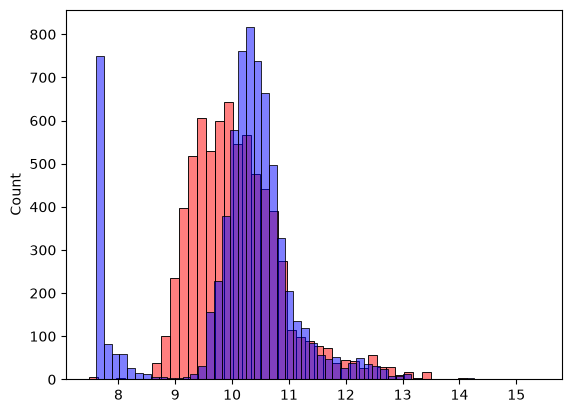

In [348]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

- The prediction distribution does not match the actual-price distribution.
- Its peak is shifted to the left, suggesting the model often underpredicts prices.
- A histogram gives a visual impression, but it is not an objective measure of model quality.
- We will use RMSE in the next unit to quantify prediction error with a single number.

# Root Mean Squared Error (RMSE)

1. The formula

- Compare the **predicted value** `g(xi)` with the **actual value** `yi`.
- Calculate the difference: `g(xi) - yi`.
- **Square** each difference.
- **Average** the squared differences over all `m` observations.
- Take the **square root** of the average.
- The result is the **RMSE (Root Mean Squared Error)**.

RMSE = sqrt( (1/m) · Σ (g(xi) - yi)² )

2. Implementation

In [349]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [350]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

- Baseline RMSE: `0.76`
- Lower RMSE = better model
- Recompute RMSE after model changes
- So far: evaluated on **training data**
- Next: evaluate on **validation data**